In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv
from utils import fetch_influx_data, query

Configurazione caricata correttamente!
 URL: http://192.168.135.209:8086 |  Bucket: monitoraggio_pi


In [4]:
test = fetch_influx_data( query=query)
test

,result,table,_start,_stop,_time,_measurement,host,stanza,percepita,temperatura,umidita
0,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:39.493281+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
1,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:44.972750+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
2,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:50.260766+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
3,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:55.544089+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
4,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:49:00.822208+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
...,...,...,...,...,...,...,...,...,...,...,...
514,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:49.209956+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
515,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:54.470097+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
516,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:59.741059+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
517,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:35:05.001349+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0


In [5]:
test.to_csv("data/days/09-agosto-2026.csv")

In [34]:
df = pd.read_csv( "data/days/09-agosto-2026.csv", parse_dates=['_time'])
df

,Unnamed: 0,result,table,_start,_stop,_time,_measurement,host,stanza,percepita,temperatura,umidita
0,0,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:39.493281+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
1,1,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:44.972750+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
2,2,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:50.260766+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
3,3,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:55.544089+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
4,4,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:49:00.822208+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...
514,514,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:49.209956+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
515,515,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:54.470097+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
516,516,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:59.741059+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
517,517,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:35:05.001349+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0


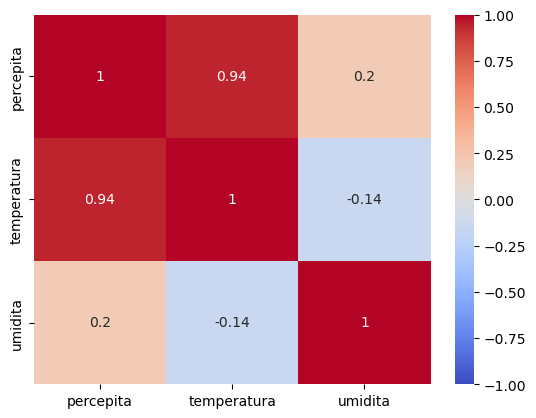

In [35]:
corr_columns = ['percepita', 'temperatura' , 'umidita']

corr_matrix  = df[corr_columns].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [8]:
corr_matrix

,percepita,temperatura,umidita
percepita,1.000000,0.941430,0.195598
temperatura,0.941430,1.000000,-0.144508
umidita,0.195598,-0.144508,1.000000


In [20]:
df

,Unnamed: 0,result,table,_start,_stop,_time,_measurement,host,stanza,percepita,temperatura,umidita
0,0,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:39.493281+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
1,1,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:44.972750+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
2,2,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:50.260766+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
3,3,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:55.544089+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
4,4,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:49:00.822208+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...
514,514,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:49.209956+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
515,515,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:54.470097+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
516,516,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:59.741059+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
517,517,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:35:05.001349+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0


In [36]:
df["_time"] = pd.to_datetime(df["_time"], format='ISO8601' )

df.set_index("_time", inplace=True)
df.groupby(df.index.hour)[
    ["percepita", "temperatura", "umidita"]
].corr()

percepita  temperatura   umidita
_time                                              
8     percepita     1.000000     0.995169 -0.629146
      temperatura   0.995169     1.000000 -0.698671
      umidita      -0.629146    -0.698671  1.000000
9     percepita     1.000000     0.946633  0.807780
      temperatura   0.946633     1.000000  0.577418
      umidita       0.807780     0.577418  1.000000

In [23]:
df

,Unnamed: 0,result,table,_start,_stop,_time,_measurement,host,stanza,percepita,temperatura,umidita
0,0,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:39.493281+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
1,1,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:44.972750+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
2,2,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:50.260766+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
3,3,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:48:55.544089+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
4,4,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 08:49:00.822208+00:00,ambiente,raspberry_pi_4,camera,34.0,33.8,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...
514,514,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:49.209956+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
515,515,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:54.470097+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
516,516,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:34:59.741059+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0
517,517,_result,0,2026-08-09 06:35:12.190901+00:00,2026-08-09 09:35:12.190901+00:00,2026-08-09 09:35:05.001349+00:00,ambiente,raspberry_pi_4,camera,34.6,34.2,35.0


<Axes: ylabel='_time-None'>

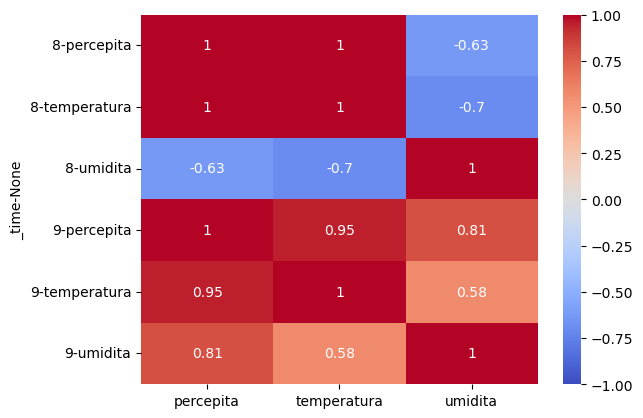

In [42]:
sns.heatmap(
df.groupby(df.index.hour)[
    ["percepita", "temperatura", "umidita"]
].corr('pearson'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)


In [41]:
df.groupby(df.index.hour)[["percepita", "temperatura", "umidita"]].aggregate({'temperatura': 'median', 'umidita': 'median', 'percepita': 'median'})

,temperatura,umidita,percepita
_time,,,
8,34.2,35.0,34.6
9,34.2,36.0,34.8
